In [85]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [86]:
# Helper functions
from anthropic.types import Message
# Helper functions


def add_user_message(messages, message):
    if isinstance(message, list):
        user_message = {
            "role": "user",
            "content": message,
        }
    else:
        user_message = {
            "role": "user",
            "content": [{"type": "text", "text": message}],
        }
    messages.append(user_message)


def add_assistant_message(messages, message):
    if isinstance(message, list):
        assistant_message = {
            "role": "assistant",
            "content": message,
        }
    elif hasattr(message, "content"):
        content_list = []
        for block in message.content:
            if block.type == "text":
                content_list.append({"type": "text", "text": block.text})
            elif block.type == "tool_use":
                content_list.append(
                    {
                        "type": "tool_use",
                        "id": block.id,
                        "name": block.name,
                        "input": block.input,
                    }
                )
        assistant_message = {
            "role": "assistant",
            "content": content_list,
        }
    else:
        # String messages need to be wrapped in a list with text block
        assistant_message = {
            "role": "assistant",
            "content": [{"type": "text", "text": message}],
        }
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message



def chat_stream(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    tool_choice=None,
    betas=[],
):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tool_choice:
        params["tool_choice"] = tool_choice

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    if betas:
        params["betas"] = betas

    return client.beta.messages.stream(**params)


def text_from_message(message):
    return "\n".join(
        [block.text for block in message.content if block.type == "text"]
    )

In [87]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

## Get Current Date Tool

In [88]:
from anthropic.types import ToolParam

def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("Date format must be provided")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the provided format string.",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A datetime format string compatible with Python's datetime.strftime (e.g., '%Y-%m-%d %H:%M:%S').",
                "default": "%Y-%m-%d %H:%M:%S",
                "minLength": 1
            }
        },
        "required": [],
        "additionalProperties": False
    }
})

In [89]:
messages = []
messages.append({
    "role": "user",
    "content": "What is the exact time, formatted as HH:MM:SS?"
})

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema],
)

messages.append({
    "role": "assistant",
    "content": response.content
})


In [90]:
res = get_current_datetime(**response.content[0].input)

In [91]:
messages.append({
    "role": "user",
    "content": [
        {
            "type": "tool_result",
            "tool_use_id": response.content[0].id,
            "content": res,
            "is_error": False
        }
    ]
})

In [92]:
messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_012nTdzv4BzroyEX8pXnqz1K', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_012nTdzv4BzroyEX8pXnqz1K',
    'content': '12:03:19',
    'is_error': False}]}]

In [93]:
response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)

In [94]:
response

Message(id='msg_01AvNJPSTEVemnXr6CV1oSqT', container=None, content=[TextBlock(citations=None, text='The exact time is **12:03:19**.', type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=726, output_tokens=14, server_tool_use=None, service_tier='standard'))

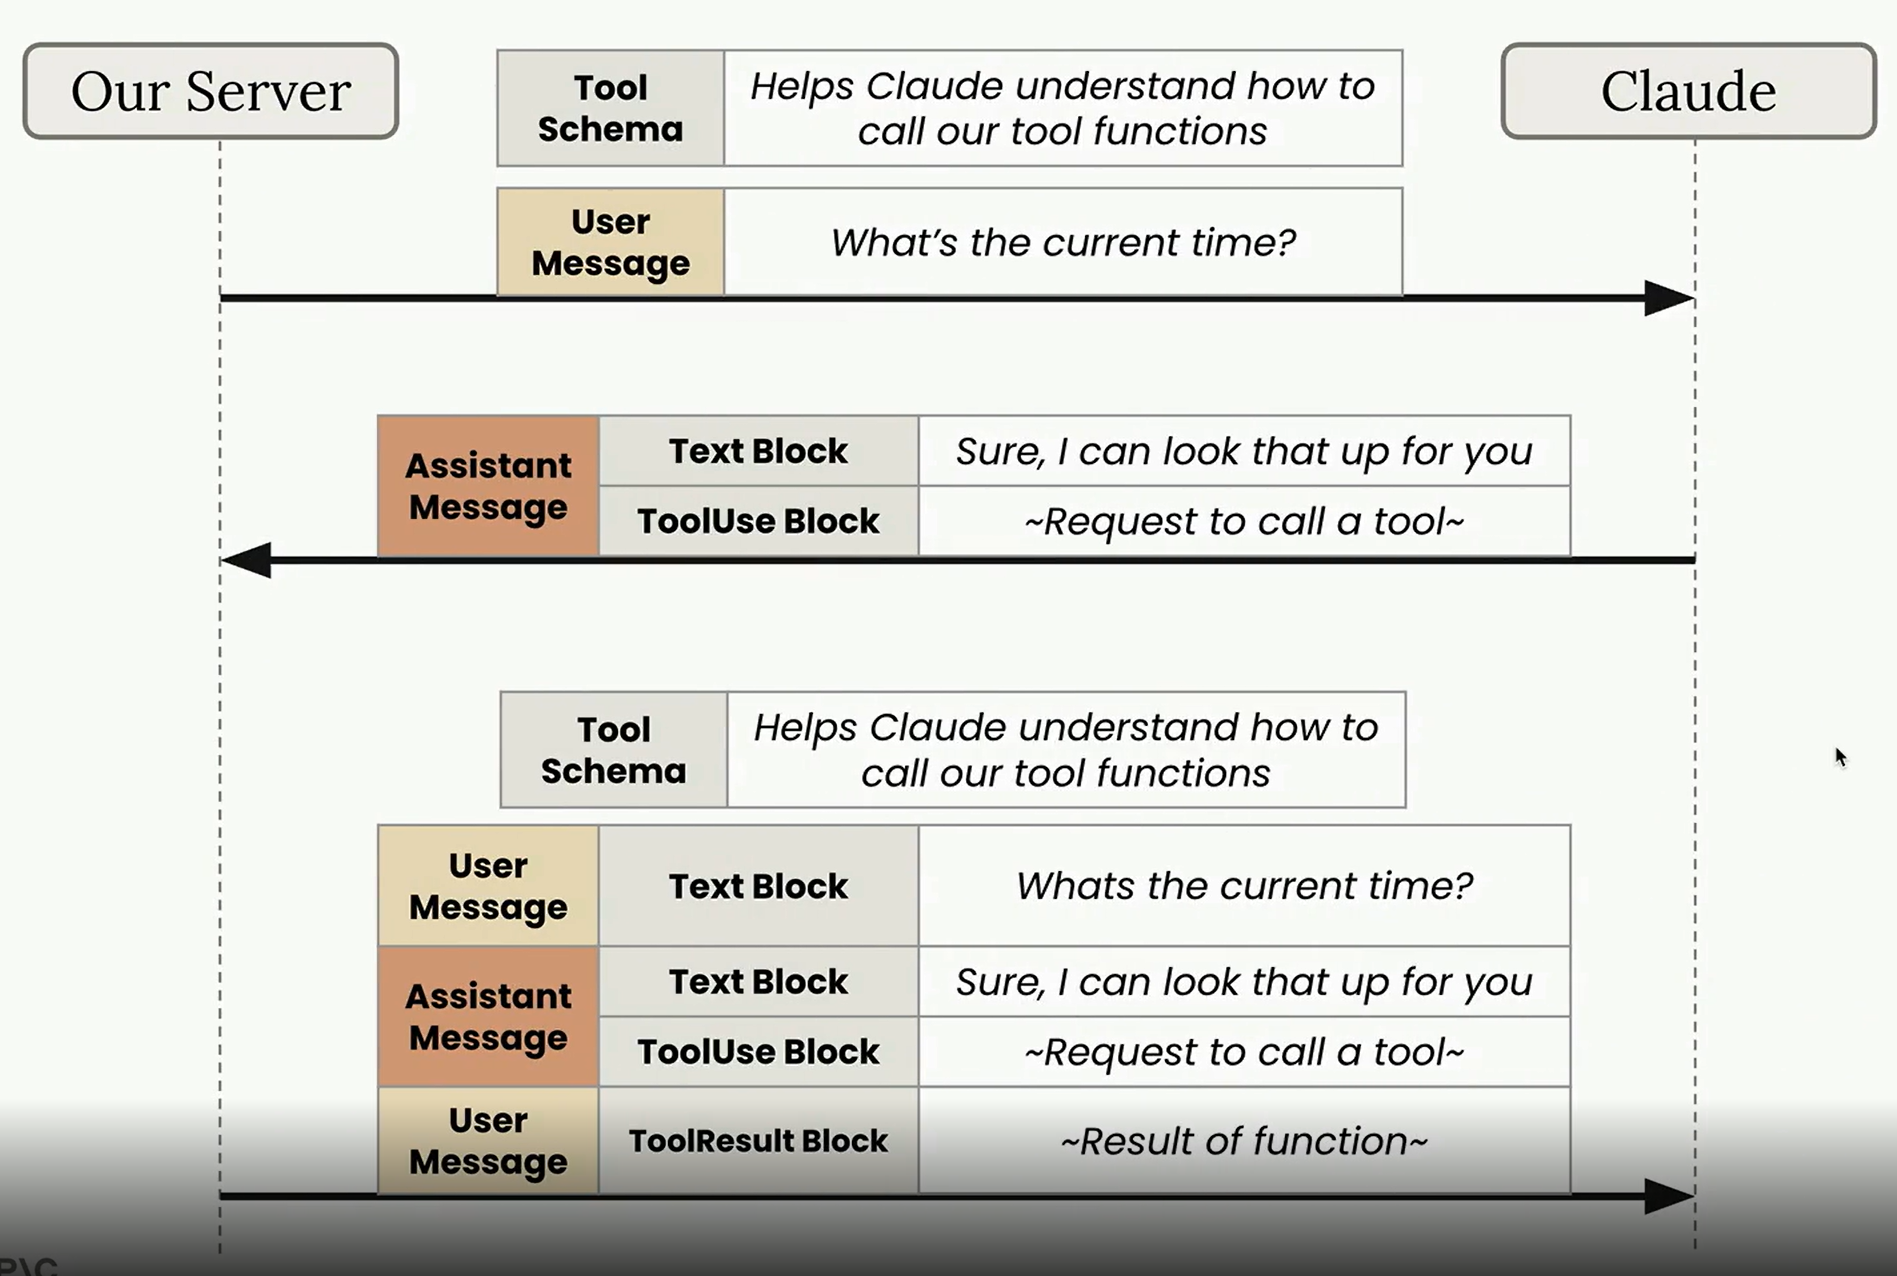

## Multiple Tools Usage 

In [95]:
import json


def run_tool(tool_name, tool_input):
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    elif tool_name == "add_duration_to_datetime":
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)
    


def run_tools(message):
    tool_requests = [block for block in message.content if block.type == "tool_use"]
    tool_result_blocks = []

    for tool_request in tool_requests:
        try:
            tool_output = run_tool(tool_request.name, tool_request.input)
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": json.dumps(tool_output),
                "is_error": False,
            }
        except Exception as e:
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": f"Error: {e}",
                "is_error": True,
            }

        tool_result_blocks.append(tool_result_block)

    return tool_result_blocks

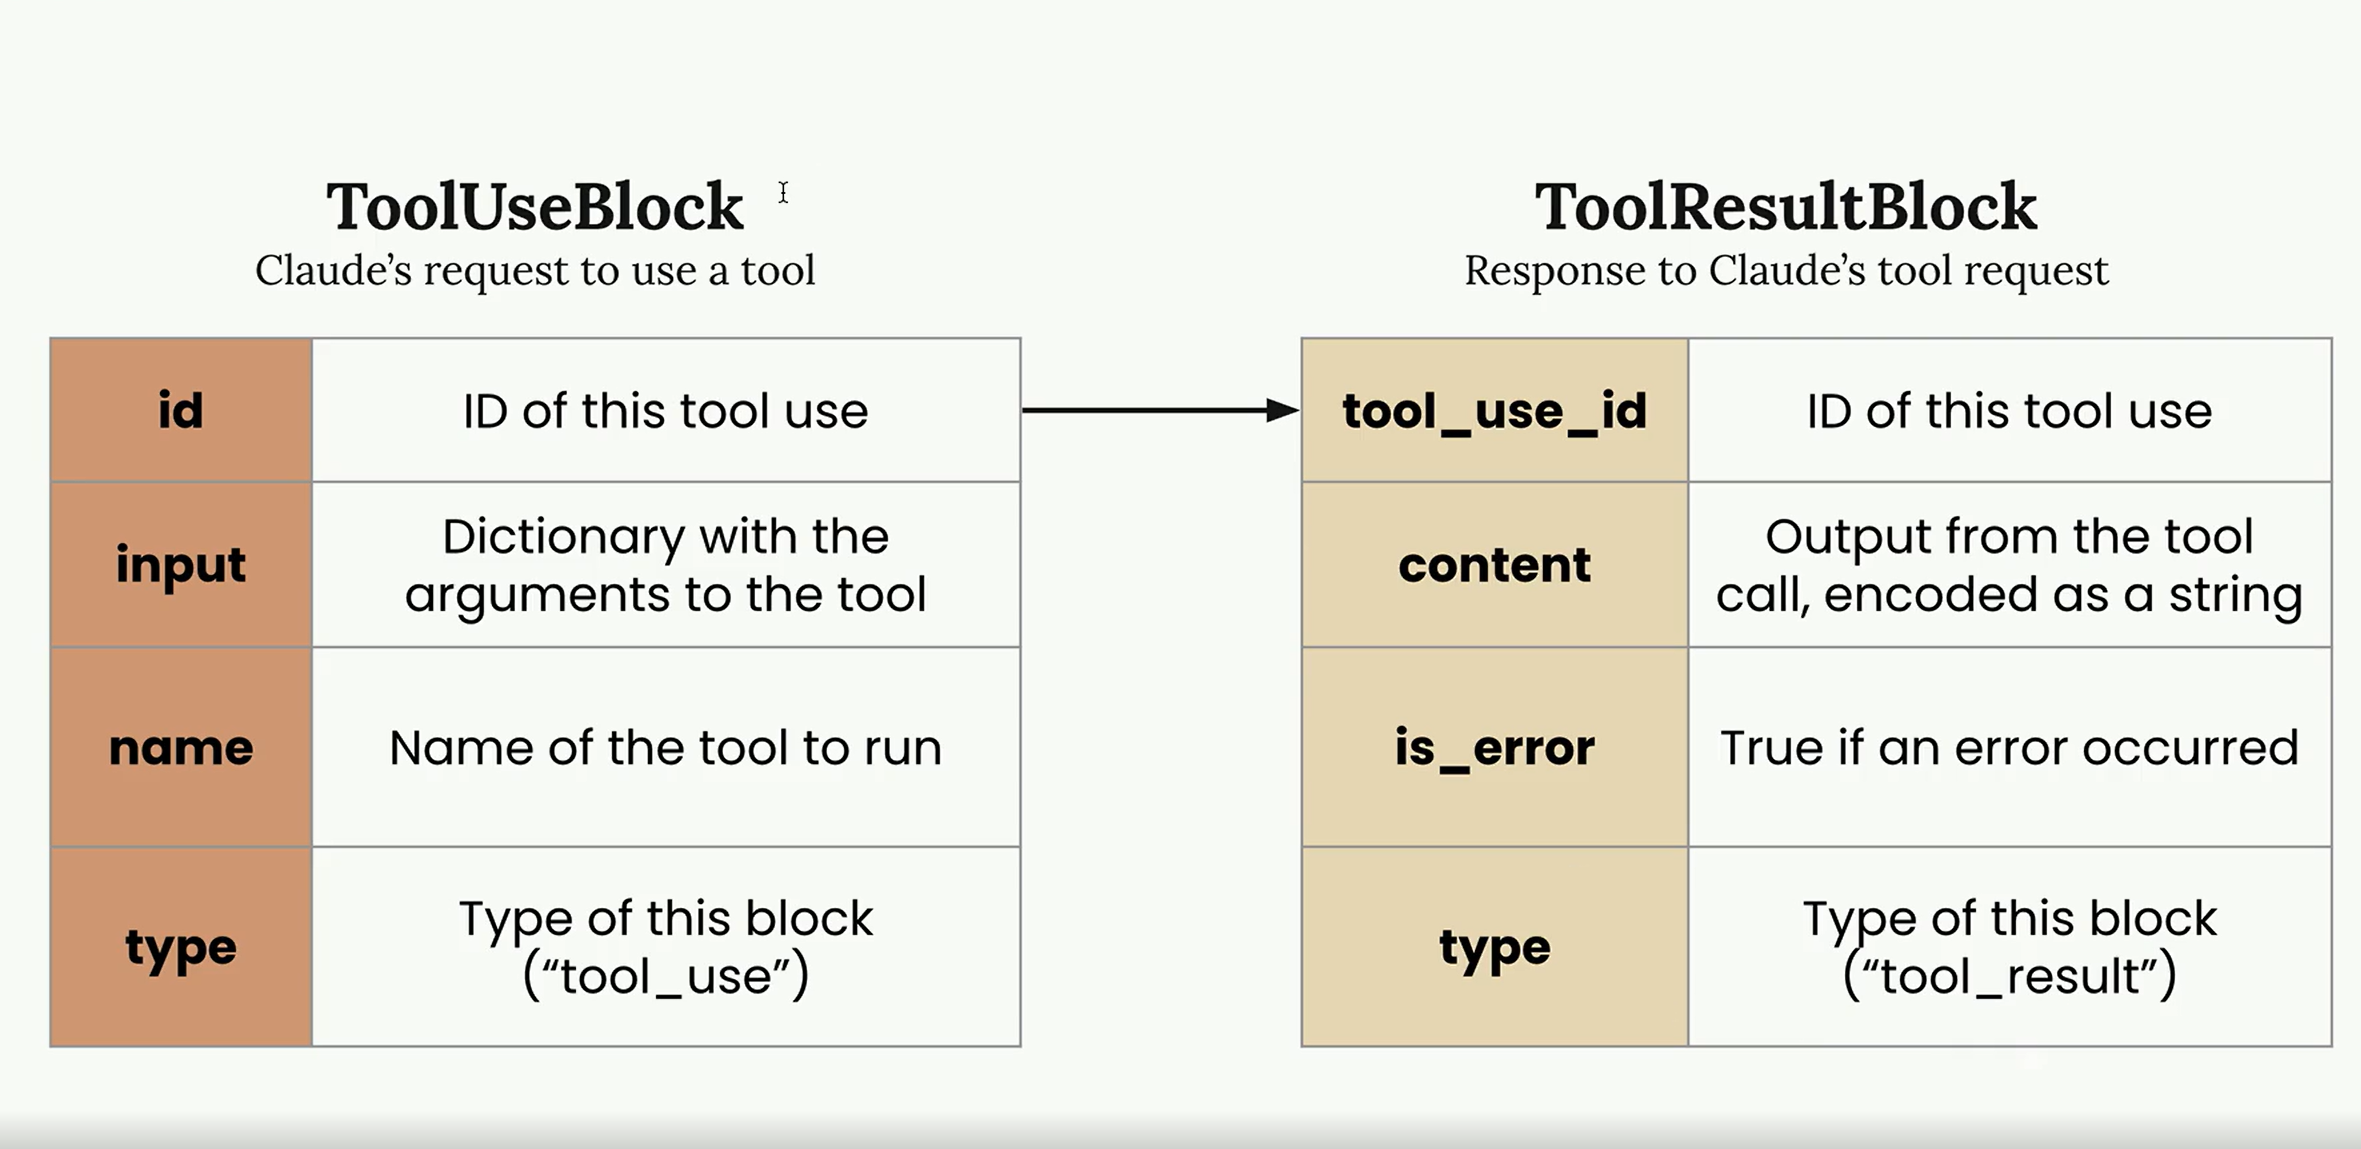

In [96]:
def run_conversation(messages):
    while True:
        response = chat(messages, tools=[
            get_current_datetime_schema,
            add_duration_to_datetime_schema,
            set_reminder_schema
            ])

        add_assistant_message(messages, response)
        print(text_from_message(response))

        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)

    return messages

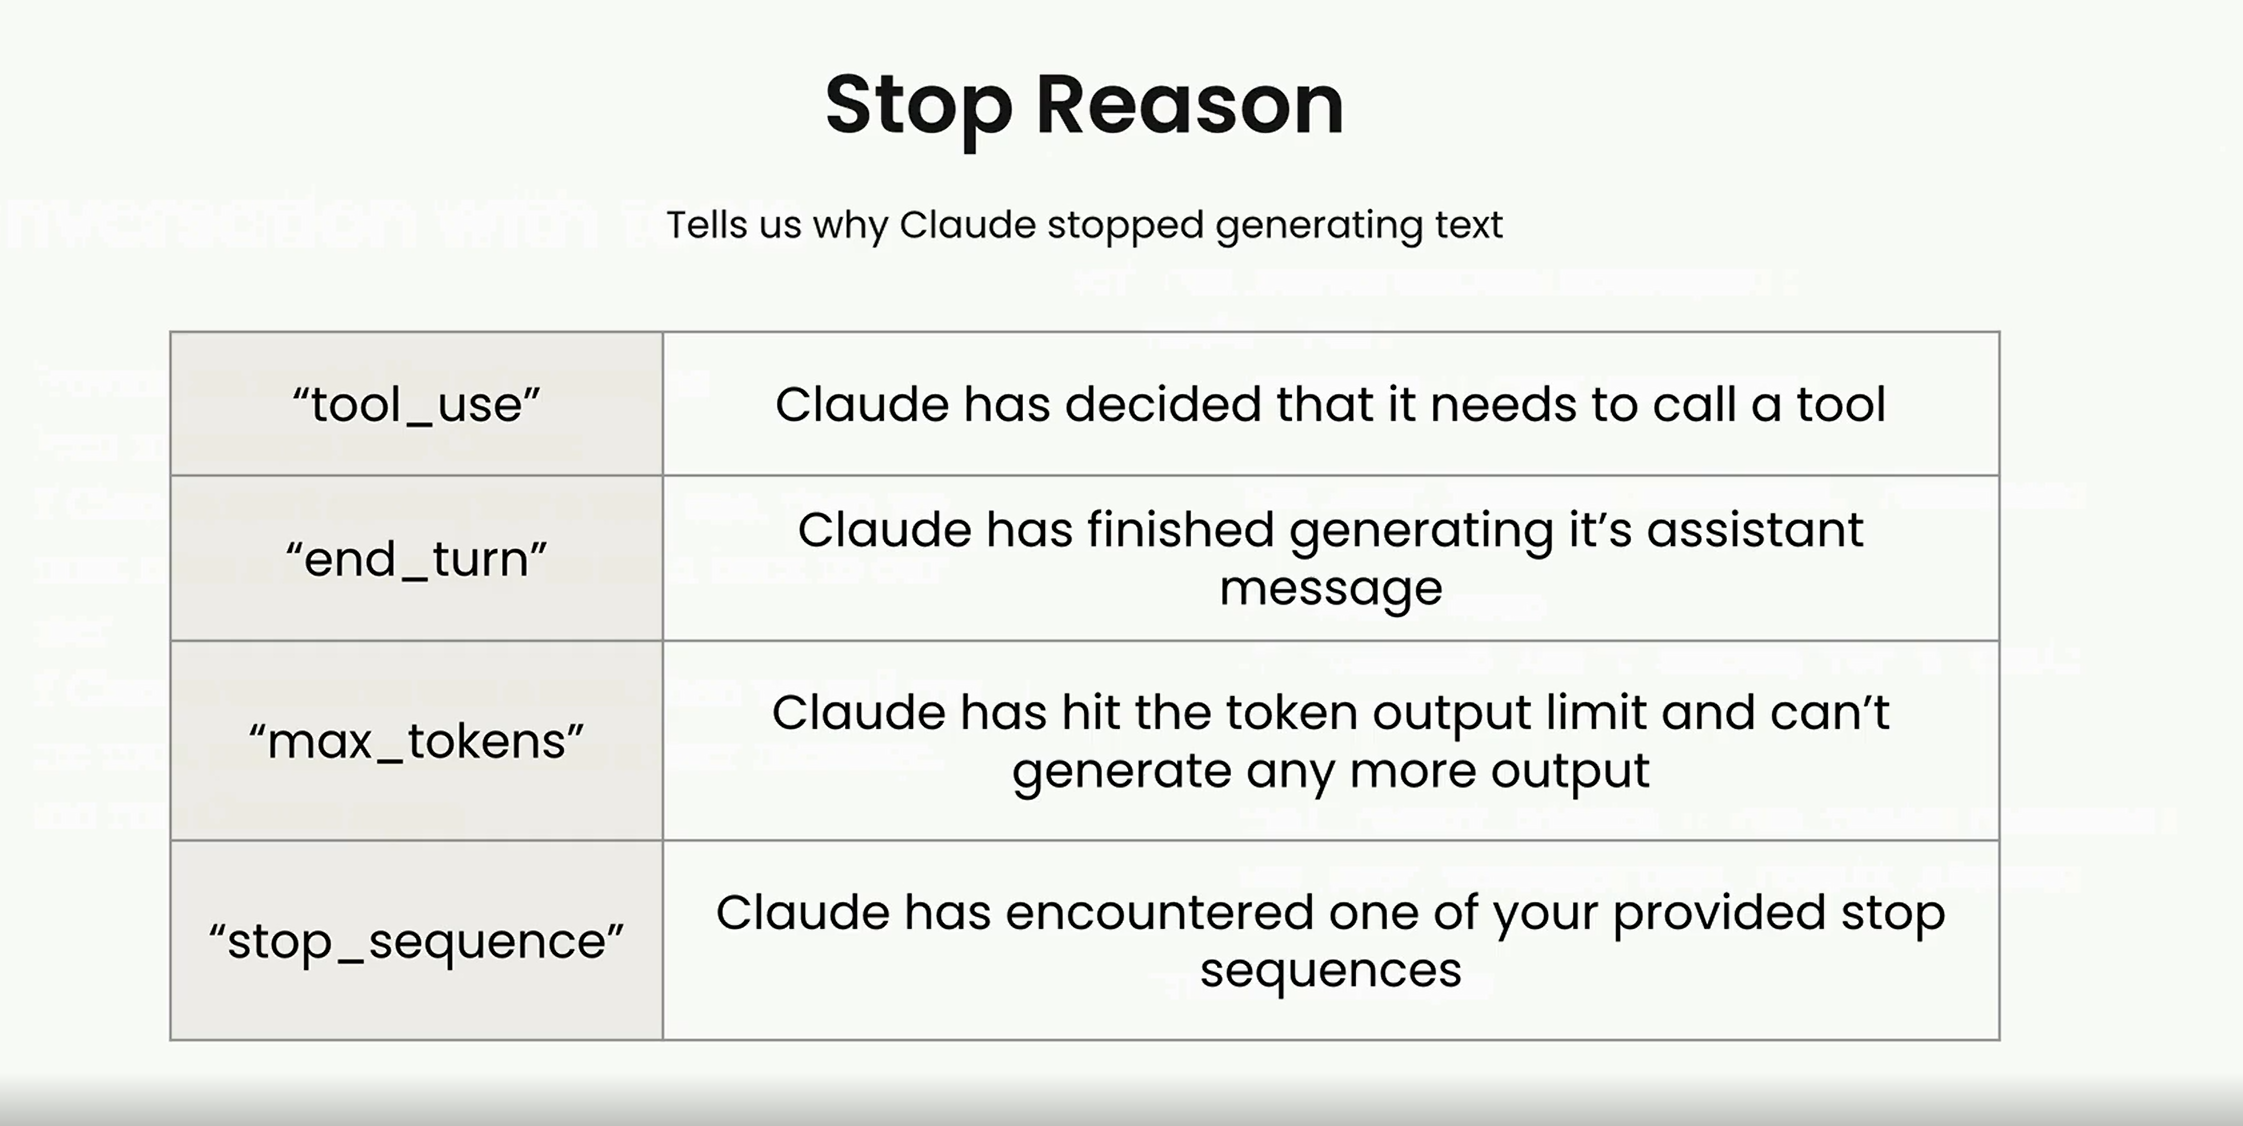

In [97]:
messages = []
add_user_message(
    messages,
    "What is the current time in HH:MM format? Also, what is the current time in SS format?",
)
run_conversation(messages)


The current time is:
- **HH:MM format**: 12:03
- **SS format**: 22 seconds

So the current time is **12:03:22**.


[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'What is the current time in HH:MM format? Also, what is the current time in SS format?'}]},
 {'role': 'assistant',
  'content': [{'type': 'tool_use',
    'id': 'toolu_01D6D5RkpTR9QS4yWsJKcNfE',
    'name': 'get_current_datetime',
    'input': {'date_format': '%H:%M'}},
   {'type': 'tool_use',
    'id': 'toolu_01KLHtXJqfSu3QXNTbkFXjmK',
    'name': 'get_current_datetime',
    'input': {'date_format': '%S'}}]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01D6D5RkpTR9QS4yWsJKcNfE',
    'content': '"12:03"',
    'is_error': False},
   {'type': 'tool_result',
    'tool_use_id': 'toolu_01KLHtXJqfSu3QXNTbkFXjmK',
    'content': '"22"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'The current time is:\n- **HH:MM format**: 12:03\n- **SS format**: 22 seconds\n\nSo the current time is **12:03:22**.'}]}]

In [98]:
messages = []
add_user_message(
    messages,
    "Set a remider for my doctor's appointment. Its 177 days after Jan 1st, 2025."
)
run_conversation(messages)

I need to calculate the date that is 177 days after January 1st, 2025. Let me do that first.
Great! The appointment is on Friday, June 27, 2025. Now let me set a reminder for you. I'll set it for the morning of that day so you have time to prepare.
----
Setting the following reminder for 2025-06-27T09:00:00:
Doctor's appointment
----
Perfect! I've set a reminder for your doctor's appointment on **Friday, June 27, 2025 at 9:00 AM**. You'll receive a notification at that time to remind you about your appointment.


[{'role': 'user',
  'content': [{'type': 'text',
    'text': "Set a remider for my doctor's appointment. Its 177 days after Jan 1st, 2025."}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'I need to calculate the date that is 177 days after January 1st, 2025. Let me do that first.'},
   {'type': 'tool_use',
    'id': 'toolu_01VHMWS1MwBugu4A5x7Cn3Ap',
    'name': 'add_duration_to_datetime',
    'input': {'datetime_str': '2025-01-01',
     'duration': 177,
     'unit': 'days'}}]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01VHMWS1MwBugu4A5x7Cn3Ap',
    'content': '"Friday, June 27, 2025 12:00:00 AM"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "Great! The appointment is on Friday, June 27, 2025. Now let me set a reminder for you. I'll set it for the morning of that day so you have time to prepare."},
   {'type': 'tool_use',
    'id': 'toolu_01X4FCGQ9PFWsFQ4RhnMWNW8',
    'name':

## With Streaming

In [99]:
# Tool definition
from anthropic.types import ToolParam

save_article_schema = ToolParam(
    {
        "name": "save_article",
        "description": "Saves a scholarly journal article",
        "input_schema": {
            "type": "object",
            "properties": {
                "abstract": {
                    "type": "string",
                    "description": "Abstract of the article. One short sentence max",
                },
                "meta": {
                    "type": "object",
                    "properties": {
                        "word_count": {
                            "type": "integer",
                            "description": "Word count",
                        },
                        "review": {
                            "type": "string",
                            "description": "Eight sentence review of the paper",
                        },
                    },
                    "required": ["word_count", "review"],
                },
            },
            "required": ["abstract", "meta"],
        },
    }
)
save_short_article_schema = ToolParam(
    {
        "name": "save_article",
        "description": "Saves a scholarly journal article",
        "input_schema": {
            "type": "object",
            "properties": {
                "abstract": {
                    "type": "string",
                    "description": "Abstract of the article. One short sentence max",
                },
                "meta": {
                    "type": "object",
                    "properties": {
                        "word_count": {
                            "type": "integer",
                            "description": "Word count",
                        },
                        "review": {
                            "type": "string",
                            "description": "Review of paper. One short sentence max",
                        },
                    },
                    "required": ["word_count", "review"],
                },
            },
            "required": ["abstract", "meta"],
        },
    }
)


def save_article(**kwargs):
    return "Article saved!"


In [100]:
# Run conversation
def run_conversation(messages, tools=[], tool_choice=None, fine_grained=False):
    while True:
        with chat_stream(
            messages,
            tools=tools,
            betas=["fine-grained-tool-streaming-2025-05-14"] if fine_grained else [],
            tool_choice=tool_choice,
        ) as stream:
            for chunk in stream:
                if chunk.type == "text":
                    print(chunk.text, end="")

                if chunk.type == "content_block_start":
                    if chunk.content_block.type == "tool_use":
                        print(f'\n>>> Tool Call: "{chunk.content_block.name}"')

                if chunk.type == "input_json" and chunk.partial_json:
                    print(chunk.partial_json, end="")

                if chunk.type == "content_block_stop":
                    print("\n")

            response = stream.get_final_message()

        add_assistant_message(messages, response)

        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)

        if tool_choice:
            break

    return messages

In [ ]:
messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
)

I'll create and save a fake computer science article for you.


>>> Tool Call: "save_article"
{"abstract": "A novel quantum-inspired algorithm for optimizing neural network training through probabilistic gradient descent in distributed computing environments.", "meta": {"word_count":4250,"review":"This paper presents an innovative approach to neural network optimization by introducing quantum-inspired probabilistic methods. The authors demonstrate significant improvements over classical gradient descent in their experimental setup with distributed systems. However, the theoretical foundations could be more rigorously established, particularly regarding convergence guarantees. The experimental section is comprehensive, testing across multiple datasets and comparing against several baseline methods. One concern is that the scalability claims lack sufficient real-world validation beyond simulated environments. The writing is generally clear but contains some dense mathematical notation th

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "I'll create and save a fake computer science article for you."},
   {'type': 'tool_use',
    'id': 'toolu_01UJ2BcdRMkupqjD26MBtXVQ',
    'name': 'save_article',
    'input': {'abstract': 'A novel quantum-inspired algorithm for optimizing neural network training through probabilistic gradient descent in distributed computing environments.',
     'meta': {'word_count': 4250,
      'review': 'This paper presents an innovative approach to neural network optimization by introducing quantum-inspired probabilistic methods. The authors demonstrate significant improvements over classical gradient descent in their experimental setup with distributed systems. However, the theoretical foundations could be more rigorously established, particularly regarding convergence guarantees. The experimental section is comprehensi

In [102]:
messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
    fine_grained=True
)


>>> Tool Call: "save_article"
{"abstract": "A novel quantum-inspired algorithm for optimizing neural network training through harmonic resonance patterns.", "meta": {
  "word_count": 8500,
  "review": "This paper presents an innovative approach to neural network optimization by leveraging quantum-inspired principles and harmonic resonance patterns. The authors demonstrate that their algorithm achieves significant speedups over traditional backpropagation methods on benchmark datasets. The theoretical foundation is well-established, building on recent advances in quantum computing and signal processing. Experimental results show a 37% improvement in convergence speed on CIFAR-10 and comparable results on ImageNet. However, the computational overhead of the harmonic analysis phase could be better addressed, and more rigorous statistical significance testing would strengthen the claims. The paper would benefit from deeper analysis of when and why the harmonic patterns emerge during train

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'tool_use',
    'id': 'toolu_016AqvodAFAsi4ixqkvkhemy',
    'name': 'save_article',
    'input': {'abstract': 'A novel quantum-inspired algorithm for optimizing neural network training through harmonic resonance patterns.',
     'meta': {'word_count': 8500,
      'review': 'This paper presents an innovative approach to neural network optimization by leveraging quantum-inspired principles and harmonic resonance patterns. The authors demonstrate that their algorithm achieves significant speedups over traditional backpropagation methods on benchmark datasets. The theoretical foundation is well-established, building on recent advances in quantum computing and signal processing. Experimental results show a 37% improvement in convergence speed on CIFAR-10 and comparable results on ImageNet. However, the computational overhead of the 